## Exercise 


Consider the following differential problem:
$$
  \begin{aligned}
    -u''(x) = f(x), \qquad&\text{for } x \in (0, 1), \\
    u(0) = u(1) = 0, \qquad &
  \end{aligned}
$$

1.  Solve the problem using the variational approach in FEniCS.
Use the space $\mathbb{P}^k$ of continuous piecewise polynomial functions with $k=1$ and $k=2$.
    
2.  Consider the load function $f=1$ and $f=\sin(\pi x)$ and, in both cases, verify the dependence of the error in the norms $L^2$ and $H^1$.



## Solution

As usual, we import *FEniCS* package together with the matplotlib module

In [2]:
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *

E: Package 'python-software-properties' has no installation candidate
Get:1 https://cloud.r-project.org/bin/linux/ubuntu bionic-cran35/ InRelease [3,626 B]
Ign:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  InRelease
Get:3 http://security.ubuntu.com/ubuntu bionic-security InRelease [88.7 kB]
Ign:4 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  InRelease
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  Release [564 B]
Hit:6 https://developer.download.nvidia.com/compute/machine-learning/repos/ubuntu1804/x86_64  Release
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu1804/x86_64  Release.gpg [819 B]
Get:8 http://ppa.launchpad.net/fenics-packages/fenics/ubuntu bionic InRelease [15.4 kB]
Hit:9 http://archive.ubuntu.com/ubuntu bionic InRelease
Get:10 https://cloud.r-project.org/bin/linux/ubuntu bionic-cran35/ Packages [87.3 kB]
Get:11 http://archive.ubuntu.com/ubuntu 

In [0]:
from fenics import *
import matplotlib.pyplot as plt

This time we define the FE solver as a python function with 3 inputs:


> The number of subintervals $n$


> The polynomial degree identifying the FE discrete space


> the load function $f$










In [0]:
def laplace_solve(n, degree, f):
    # Step 1. Mesh generation
    mesh = UnitIntervalMesh(n)

    # Step 2a. Definition of finite element space
    V = FunctionSpace(mesh, 'CG', degree)

    # Step 2b. Boundary conditions
    g_boundary = Constant(0.0)

    def boundary(x, on_boundary):
        return on_boundary

    bc = DirichletBC(V, g_boundary, boundary)

    # Step 3. Assembling matrices and vectors
    u = TrialFunction(V)
    v = TestFunction(V)

    a = dot(grad(u), grad(v)) * dx
    L = f * v * dx

    # Step 4. Solve the linear system
    u = Function(V)
    solve(a == L, u, bc)

    return u

Then, we solve for both given load functions and polynomial degree.

In order to verify the convergence rate, let us half the mesh size progressively keeping fixed the polinomyal degree, the numerical solution is compared with the exact solution. Error in the norms $L^2$ and $H^1$ are computed:
\begin{equation*}
  ||u - u_h||_{L^2(0,1)} = \sqrt{\int_0^1 {|u - u_h|}^2 \, dx}, \qquad
  |u - u_h|_{H^1(0,1)} = ||u' - u_h'||_{L^2(0,1)}.
\end{equation*}
*(Note that only the seminorm $H^1$ is computed and not the full norm. In this way we are going to measure the error only for $u'$, without the contribute of the error in $u$.)*

In [5]:
for degree in [1, 2]:
    f1 = Constant(1)
    u1 = Expression('x[0] * (1 - x[0]) / 2', degree=degree+2)

    f2 = Expression('sin(pi * x[0])', degree=degree+1)
    u2 = Expression('sin(pi * x[0]) / pi / pi', degree=degree+2)

    print('f = 1')
    print('------------------------------------------------')
    for n in [10, 20, 40, 80, 160]:
        uh = laplace_solve(n, degree, f1)

        eL2 = errornorm(u1, uh, 'L2')
        eH1 = errornorm(u1, uh, 'H10')

        print('n={} degree={} eL2={:.2e} eH1={:.2e}'.format(n, degree, eL2, eH1));
    print()

    print('f = sin(pi x)')
    print('------------------------------------------------')
    for n in [10, 20, 40, 80, 160]:
        uh = laplace_solve(n, degree, f2)

        eL2 = errornorm(u2, uh, 'L2')
        eH1 = errornorm(u2, uh, 'H10')

        print('n={} degree={} eL2={:.2e} eH1={:.2e}'.format(n, degree, eL2, eH1));
    print()

f = 1
------------------------------------------------
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
n=10 degree=1 eL2=9.13e-04 eH1=2.89e-02
n=20 degree=1 eL2=2.28e-04 eH1=1.44e-02
n=40 de

#### **Exercise:** for the approximating solutions above, evaluate the order of convergence

### Exact solutions

In this 1D problem, we can explicitly compute the solution by integrating the strong formulation
of the problem:
\begin{align*}
  u(x) &= u(0) + \int_0^x u'(s) \, ds = \\
       &= u(0) + \int_0^x \left(u'(0) + \int_0^s u''(t) \, dt \right) \, ds = \\
       &= u(0) + x u'(0) - \int_0^x \int_0^s f(t) \, dt \, ds = \\
       &= u(0) + x u'(0) - \int_0^x (x - s) f(s) \, ds.
\end{align*}
Where $u(0) = 0$ and $u'(0)$ is determined by the boundary condition $u(1) =
0$:
\begin{equation*}
  u(1) = u'(0) - \int_0^1 (1 - s) f(s) \, ds
  \implies
  u'(0) = \int_0^1 (1 - s) f(s) \, ds,
\end{equation*}
so that
\begin{equation*}
  u(x) = x \int_0^1 (1 - s) f(s) \, ds - \int_0^x (x - s) f(s) \, ds.
\end{equation*}

For load $f(x)=1$ we simply get $u(x) = \frac{x(1-x)}2$. The exact solution belongs to discrete space for degree $k=2$.

For load $f(x)=\sin(\pi x)$ we simply get $u(x) = \frac{\sin(\pi x)}{\pi^2}$.

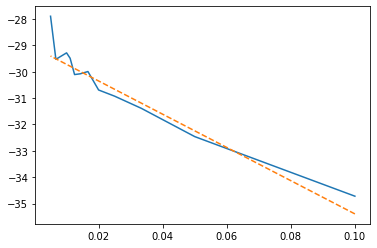

In [24]:
# check that discrete and exact solution "coincides"
import numpy as np
f1 = Constant(1)
u1 = Expression('x[0] * (1 - x[0]) / 2', degree=degree+2)
error_max_vect=[]
h=[]
for n in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]:
  mesh = UnitIntervalMesh(n)
  V = FunctionSpace(mesh, 'CG', 2)

  uh = laplace_solve(n, 2, f1)

  # to compute the interpolate of the exact solution use
  ui = interpolate(u1,V)

  # simple nodal check
  nodal_values_uh = uh.vector()
  nodal_values_ui = ui.vector()
  #print(nodal_values_uh[20],nodal_values_ui[20])

  vertex_values_u1 = u1.compute_vertex_values(mesh)
  vertex_values_uh = uh.compute_vertex_values(mesh)
  vertex_values_ui = ui.compute_vertex_values(mesh)

  # check on the mesh vertices
  error_max = np.max(np.abs(vertex_values_uh - vertex_values_u1))
  error_max_vect.append(error_max)
  h.append(1/n)
  error_max_int = np.max(np.abs(vertex_values_u1 - vertex_values_ui))
  #print(error_max, error_max_int)

plt.plot(h, np.log(error_max_vect))
plt.plot([h[0], h[-1]], [-2*np.log(h[0])-40, -2*np.log(h[-1])-40], '--')

In [0]:
# Plot solutions
uh1 = laplace_solve(8, 1, f2)
uh2 = laplace_solve(80, 1, f2)

plt.subplot(1,2,1)
plot(uh1, title = "Solution with 9 dofs")
plt.subplot(1,2,2)
plot(uh2, title = "Solution with 81 dfos")

In [0]:
help(plot)